In [ ]:
! sudo apt-get update

Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [110 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [993 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [119 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [966 kB]
Get:8 https://ppa.launchpadcontent.net/c2d4u.team/c2d4u4.0+/ubuntu jammy InRelease [18.1 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [109 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,257 kB]
Hit:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [1,235 kB]
Hit:13 https://ppa.launchpadcon

In [ ]:
 #innstall java
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# install spark (change the version number if needed)
!wget -q https://archive.apache.org/dist/spark/spark-3.0.0/spark-3.0.0-bin-hadoop3.2.tgz

# unzip the spark file to the current folder
!tar xf spark-3.0.0-bin-hadoop3.2.tgz

# set your spark folder to your system path environment.
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.0.0-bin-hadoop3.2"


# install findspark using pip
!pip install -q findspark

#For python users, you should also install pyspark using the following command.

!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.8/310.8 MB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.4.1-py2.py3-none-any.whl size=311285387 sha256=9c5507eddb35d87a877a2f15189fb1da5a109a7f86015f09261fa41908d409fe
  Stored in directory: /root/.cache/pip/wheels/0d/77/a3/ff2f74cc9ab41f8f594dabf0579c2a7c6de920d584206e0834
Successfully built pyspark


In [ ]:
import findspark
findspark.init()

In [ ]:
from google.colab import files
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import isnan, when, count, col, lit,to_date ,hour ,minute ,countDistinct
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.tuning import CrossValidator
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import StandardScaler
import pandas as pd
import numpy as np
import seaborn as sb
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

In [ ]:
sc =SparkSession.builder.master("local").getOrCreate()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df1 = sc.read.csv('/content/drive/MyDrive/block0_df_ml_model.csv' , inferSchema = True ,header = True)

In [ ]:
df1 = df1.drop('_c0')
df1 = df1.dropDuplicates()
df1.count()

19612

In [ ]:
df1.show(5)

+------------------+------------+-------------------+-------------------+-----+--------+
|       sum(energy)|count(LCLid)|              time2|apparentTemperature|hour2|week_end|
+------------------+------------+-------------------+-------------------+-----+--------+
|1.5479999482631683|         4.0|2012-04-08 07:00:00|               5.03|  7.0|       1|
| 5.970000050961971|         5.0|2012-04-22 22:00:00|               5.14| 22.0|       1|
|3.0740000158548355|         7.0|2012-06-15 04:00:00|               13.2|  4.0|       0|
| 7.218999914824963|        10.0|2012-07-28 00:00:00|              16.84|  0.0|       1|
| 6.906999919563532|        10.0|2012-08-11 16:00:00|              21.23| 16.0|       1|
+------------------+------------+-------------------+-------------------+-----+--------+
only showing top 5 rows



In [ ]:
df1 =df1.withColumnRenamed('hour2','hour')

In [ ]:
df1 = df1.na.drop()

In [ ]:
from pyspark.ml.feature import OneHotEncoder
stages = []
column_list = ['hour' ,'week_end']
for column in column_list :
  encoder = OneHotEncoder(inputCol=column, outputCol=column+"_encoded")
  stages.append(encoder)
pipeline = Pipeline(stages = stages )
df_encoded = pipeline.fit(df1).transform(df1)

In [ ]:
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler
vector_assembler = VectorAssembler(inputCols = ['hour_encoded','apparentTemperature',
                                                'week_end_encoded','count(LCLid)']
                                   ,outputCol = 'features_vector')
df = vector_assembler.transform(df_encoded)
df.show(3)

+------------------+------------+-------------------+-------------------+----+--------+---------------+----------------+--------------------+
|       sum(energy)|count(LCLid)|              time2|apparentTemperature|hour|week_end|   hour_encoded|week_end_encoded|     features_vector|
+------------------+------------+-------------------+-------------------+----+--------+---------------+----------------+--------------------+
|1.5479999482631683|         4.0|2012-04-08 07:00:00|               5.03| 7.0|       1| (23,[7],[1.0])|       (1,[],[])|(26,[7,23,25],[1....|
| 5.970000050961971|         5.0|2012-04-22 22:00:00|               5.14|22.0|       1|(23,[22],[1.0])|       (1,[],[])|(26,[22,23,25],[1...|
|3.0740000158548355|         7.0|2012-06-15 04:00:00|               13.2| 4.0|       0| (23,[4],[1.0])|   (1,[0],[1.0])|(26,[4,23,24,25],...|
+------------------+------------+-------------------+-------------------+----+--------+---------------+----------------+--------------------+
only s

In [ ]:
from pyspark.ml import Pipeline
# expansion parameters
from pyspark.ml.feature import PolynomialExpansion
poly = PolynomialExpansion(degree =2 ,inputCol='features_vector', outputCol='poly_features')
df = poly.transform(df)
df_train ,df_test = df.randomSplit([0.8,0.2])

In [ ]:
ss = StandardScaler(withMean=True, withStd=True, inputCol='poly_features' , outputCol='poly_features_scaled')
ss_model =ss.fit(df_train)
df_train = ss_model.transform(df_train)
df_test = ss_model.transform(df_test)

In [ ]:
df_train.show(2)

+--------------------+------------+-------------------+-------------------+----+--------+---------------+----------------+--------------------+--------------------+--------------------+
|         sum(energy)|count(LCLid)|              time2|apparentTemperature|hour|week_end|   hour_encoded|week_end_encoded|     features_vector|       poly_features|poly_features_scaled|
+--------------------+------------+-------------------+-------------------+----+--------+---------------+----------------+--------------------+--------------------+--------------------+
| 0.05400000140070915|         1.0|2011-12-06 18:00:00|               3.39|18.0|       0|(23,[18],[1.0])|   (1,[0],[1.0])|(26,[18,23,24,25]...|(377,[189,208,299...|[-0.2091087833383...|
|0.054999999701976776|         1.0|2012-02-06 06:00:00|               1.46| 6.0|       0| (23,[6],[1.0])|   (1,[0],[1.0])|(26,[6,23,24,25],...|(377,[27,34,299,3...|[-0.2091087833383...|
+--------------------+------------+-------------------+---------------

In [ ]:
from pyspark.ml.regression import LinearRegression
# elasticnetparam = 0 --> ridge regression (L2 penalty )
lr = LinearRegression( featuresCol='poly_features_scaled', labelCol='sum(energy)',elasticNetParam=0)
pipeline = Pipeline(stages = [lr])
pipeline.write().overwrite().save("pipeline")
pipelineModel = Pipeline.load("pipeline")
from pyspark.ml.tuning import ParamGridBuilder
paramGrid =  ParamGridBuilder().build()
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(predictionCol='prediction', labelCol='sum(energy)', metricName='r2')
crossval = CrossValidator(estimator=pipelineModel,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=2
                          ,collectSubModels=True
                          )

In [ ]:
from time import time
t0 = time()
cvmodel = crossval.fit(df_train)
fitting_time_lr = time() - t0

In [ ]:
t0 = time()
pred_plain = cvmodel.transform(df_test)
predicting_time_lr = time() - t0

In [ ]:
from pyspark.sql import functions as F
pred_plain=pred_plain.withColumn(
    "prediction",
    F.when(pred_plain["prediction"] < 0, 0.1).otherwise(F.col("prediction")))

In [ ]:
eval =RegressionEvaluator(labelCol="sum(energy)")
r2_plain = eval.evaluate(pred_plain,{eval.metricName:"r2"})
mae_plain = eval.evaluate(pred_plain,{eval.metricName:"mae"})
rmse_plain = eval.evaluate(pred_plain,{eval.metricName:"rmse"})
mse_plain = eval.evaluate(pred_plain,{eval.metricName:"mse"})
print('r2 of plain= ', r2_plain)
print('mae of plain= ', mae_plain)
print('rmse of plain = ', rmse_plain)
print('mse of plain= ',mse_plain)

r2 of plain=  0.9435088871878967
mae of plain=  1.723868624716734
rmse of plain =  2.5140443515399657
mse of plain=  6.320419001510007


In [ ]:
plain_coeffs = cvmodel.bestModel.stages[0].coefficients.values.tolist()

In [ ]:
df_features = pd.DataFrame(df.schema["features_vector"].metadata["ml_attr"]["attrs"]["binary"]+df.schema["features_vector"].metadata["ml_attr"]["attrs"]["numeric"]).sort_values("idx")
features_list = df_features['name'].tolist()

In [ ]:
len(features_list)

26

In [ ]:
features_list.insert(0,str(1))

In [ ]:
poly_features_list = []
for i in range(1,27):
  for j in range(i+1):
    poly_features_list.append(features_list[i] + '*' +features_list[j])

In [ ]:
len(poly_features_list)

377

In [ ]:
d = {'features':poly_features_list , 'coefficients' :plain_coeffs }
df_features_coeffs = pd.DataFrame(data = d)

In [ ]:
df_features_coeffs

,features,coefficients
0,hour_encoded_0*1,-0.066546
1,hour_encoded_0*hour_encoded_0,-0.066546
2,hour_encoded_1*1,-0.174495
3,hour_encoded_1*hour_encoded_0,0.000000
4,hour_encoded_1*hour_encoded_1,-0.174495
...,...,...
372,count(LCLid)*hour_encoded_21,1.609062
373,count(LCLid)*hour_encoded_22,0.904423
374,count(LCLid)*apparentTemperature,-3.281380
375,count(LCLid)*week_end_encoded_0,-0.529082


In [ ]:
df_features_coeffs['coefficients_abs'] = df_features_coeffs['coefficients'].apply(abs)
df_features_coeffs.sort_values(by= 'coefficients_abs',ascending=False)

,features,coefficients,coefficients_abs
350,count(LCLid)*1,15.687778,15.687778
376,count(LCLid)*count(LCLid),-5.164692,5.164692
374,count(LCLid)*apparentTemperature,-3.281380,3.281380
370,count(LCLid)*hour_encoded_19,1.968022,1.968022
371,count(LCLid)*hour_encoded_20,1.865379,1.865379
...,...,...,...
199,hour_encoded_18*hour_encoded_9,0.000000,0.000000
200,hour_encoded_18*hour_encoded_10,0.000000,0.000000
201,hour_encoded_18*hour_encoded_11,0.000000,0.000000
202,hour_encoded_18*hour_encoded_12,0.000000,0.000000


In [ ]:
df_features_coeffs_nonzero = df_features_coeffs[df_features_coeffs['coefficients_abs'] >0.01]
df_features_coeffs_nonzero.shape

(119, 3)

## Lasso model

In [ ]:
## lasoo
from pyspark.ml.regression import LinearRegression
# elasticnetparam = 0 --> ridge regression (L2 penalty )
lr =LinearRegression( featuresCol='poly_features_scaled', labelCol='sum(energy)',elasticNetParam=1)
pipeline = Pipeline(stages = [lr])
pipeline.write().overwrite().save("pipeline")
pipelineModel = Pipeline.load("pipeline")
# elasticNetParam = Param(parent='undefined', name='elasticNetParam',
#doc='the ElasticNet mixing parameter, in range [0, 1]. For alpha = 0,
#the penalty is an L2 penalty (ridge). For alpha = 1, it is an L1 penalty. (lasso)')
from pyspark.ml.tuning import ParamGridBuilder
paramGrid =  ParamGridBuilder().addGrid(lr.regParam, [1,0.1,0.01,0.001,0.0001,0.00001]).build()
#paramGrid =  ParamGridBuilder().build()
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(predictionCol='prediction', labelCol='sum(energy)', metricName='r2')
crossval = CrossValidator(estimator=pipelineModel,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=4 ,collectSubModels=True)


In [ ]:
t0 = time()
cvmodel_lasso = crossval.fit(df_train)
fitting_time_lasso = time() - t0

In [ ]:
print(cvmodel_lasso.getEstimatorParamMaps()[np.argmax(cvmodel_lasso.avgMetrics)])

{Param(parent='LinearRegression_80dd3bc1a764', name='regParam', doc='regularization parameter (>= 0).'): 1e-05}


In [ ]:
cvmodel_lasso.avgMetrics

[0.7621106921420316,
 0.9271559585354678,
 0.9424992802891683,
 0.943017029585927,
 0.9431509398041047,
 0.9433183761257418]

In [ ]:
pd.DataFrame(models)

,1.00000,0.10000,0.01000,0.00100,0.00010,0.00001
0,0.000000,0.000000,0.000000,-0.116309,-0.132005,-0.127727
1,0.000000,0.000000,0.000000,-0.116309,-0.132005,-0.127727
2,0.000000,0.000000,-0.047996,-0.222377,-0.230523,-0.231547
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,-0.047996,-0.222377,-0.230523,-0.231547
...,...,...,...,...,...,...
372,0.955204,1.460495,1.566623,1.765306,1.923199,1.868352
373,0.272621,0.774217,0.824253,1.019213,1.171510,1.136797
374,0.000000,-2.608328,-3.536633,-3.669270,-3.349197,-3.569678
375,0.000000,0.000000,-0.373821,-0.400393,-0.433322,-0.323384


In [ ]:
t0 = time()
pred_lasso = cvmodel_lasso.transform(df_test)
predicting_time_lasso = time() - t0
pred_lasso=pred_lasso.withColumn(
    "prediction",
    F.when(pred_lasso["prediction"] < 0, 0.2).otherwise(F.col("prediction")))

In [ ]:
eval =RegressionEvaluator(labelCol="sum(energy)")
r2_lasso = eval.evaluate(pred_lasso,{eval.metricName:"r2"})
rmse_lasso= eval.evaluate(pred_lasso,{eval.metricName:"rmse"})
mse_lasso= eval.evaluate(pred_lasso,{eval.metricName:"mse"})
mae_lasso= eval.evaluate(pred_lasso,{eval.metricName:"mae"})
print('r2 of lasso=' ,r2_lasso)
print('rmse of lasso= ',rmse_lasso)
print('mse of lasso=' , mse_lasso)
print('mae of lasso= ', mae_lasso)

r2 of lasso= 0.9433942270389692
rmse of lasso=  2.5165944391803934
mse of lasso= 6.333247571313678
mae of lasso=  1.734173790669357


In [ ]:
models = {}
for l in cvmodel_lasso.subModels:
  for m in l:
    #print(m.stages[0].coefficients)
    #print(m.stages[0].getRegParam())
    models[m.stages[0].getRegParam()]= m.stages[0].coefficients.values.tolist() ## dcit for one fold

In [ ]:
models

{1.0: DenseVector([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0

In [ ]:
sub_model = pd.DataFrame(models , index = poly_features_list)
top = sub_model.abs().sort_values(by = [0.001],ascending = False)
top.loc['count(LCLid)*count(LCLid)']

1.00000    0.000000
0.10000    0.000000
0.01000    1.978581
0.00100    2.680402
0.00010    4.060225
0.00001    3.439674
Name: count(LCLid)*count(LCLid), dtype: float64

In [ ]:
top = top.head()

In [ ]:
top

,1.00000,0.10000,0.01000,0.00100,0.00010,0.00001
count(LCLid)*1,7.011007,9.915900,12.626173,12.950634,13.690824,13.236799
count(LCLid)*apparentTemperature,0.000000,2.608328,3.536633,3.669270,3.349197,3.569678
count(LCLid)*count(LCLid),0.000000,0.000000,1.978581,2.680402,4.060225,3.439674
count(LCLid)*hour_encoded_19,1.118740,1.815387,1.920166,2.138463,2.270277,2.234855
count(LCLid)*hour_encoded_20,1.191015,1.753128,1.808457,2.007814,2.165696,2.125400


import numpy as np
from google.colab import autoviz

def value_plot(df, y, figscale=1):
  from matplotlib import pyplot as plt
  df[y].plot(kind='line', figsize=(8 * figscale, 4 * figscale), title=y)
  plt.gca().spines[['top', 'right']].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(top, *[1.0], **{})
chart

import numpy as np
from google.colab import autoviz

def value_plot(df, y, figscale=1):
  from matplotlib import pyplot as plt
  df[y].plot(kind='line', figsize=(8 * figscale, 4 * figscale), title=y)
  plt.gca().spines[['top', 'right']].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(top, *[0.1], **{})
chart

import numpy as np
from google.colab import autoviz

def value_plot(df, y, figscale=1):
  from matplotlib import pyplot as plt
  df[y].plot(kind='line', figsize=(8 * figscale, 4 * figscale), title=y)
  plt.gca().spines[['top', 'right']].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(top, *[0.01], **{})
chart

import numpy as np
from google.colab import autoviz

def value_plot(df, y, figscale=1):
  from matplotlib import pyplot as plt
  df[y].plot(kind='line', figsize=(8 * figscale, 4 * figscale), title=y)
  plt.gca().spines[['top', 'right']].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(top, *[0.001], **{})
chart

import numpy as np
from google.colab import autoviz

def histogram(df, colname, num_bins=20, figscale=1):
  from matplotlib import pyplot as plt
  df[colname].plot(kind='hist', bins=num_bins, title=colname, figsize=(8*figscale, 4*figscale))
  plt.gca().spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = histogram(top, *[1.0], **{})
chart

import numpy as np
from google.colab import autoviz

def histogram(df, colname, num_bins=20, figscale=1):
  from matplotlib import pyplot as plt
  df[colname].plot(kind='hist', bins=num_bins, title=colname, figsize=(8*figscale, 4*figscale))
  plt.gca().spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = histogram(top, *[0.1], **{})
chart

import numpy as np
from google.colab import autoviz

def histogram(df, colname, num_bins=20, figscale=1):
  from matplotlib import pyplot as plt
  df[colname].plot(kind='hist', bins=num_bins, title=colname, figsize=(8*figscale, 4*figscale))
  plt.gca().spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = histogram(top, *[0.01], **{})
chart

import numpy as np
from google.colab import autoviz

def histogram(df, colname, num_bins=20, figscale=1):
  from matplotlib import pyplot as plt
  df[colname].plot(kind='hist', bins=num_bins, title=colname, figsize=(8*figscale, 4*figscale))
  plt.gca().spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = histogram(top, *[0.001], **{})
chart

import numpy as np
from google.colab import autoviz

def scatter_plots(df, colname_pairs, figscale=1, alpha=.8):
  from matplotlib import pyplot as plt
  plt.figure(figsize=(len(colname_pairs) * 6 * figscale, 6 * figscale))
  for plot_i, (x_colname, y_colname) in enumerate(colname_pairs, start=1):
    ax = plt.subplot(1, len(colname_pairs), plot_i)
    df.plot(kind='scatter', x=x_colname, y=y_colname, s=(32 * figscale), alpha=alpha, ax=ax)
    ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = scatter_plots(top, *[[[1.0, 0.1], [0.1, 0.01], [0.01, 0.001], [0.001, 0.0001]]], **{})
chart

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

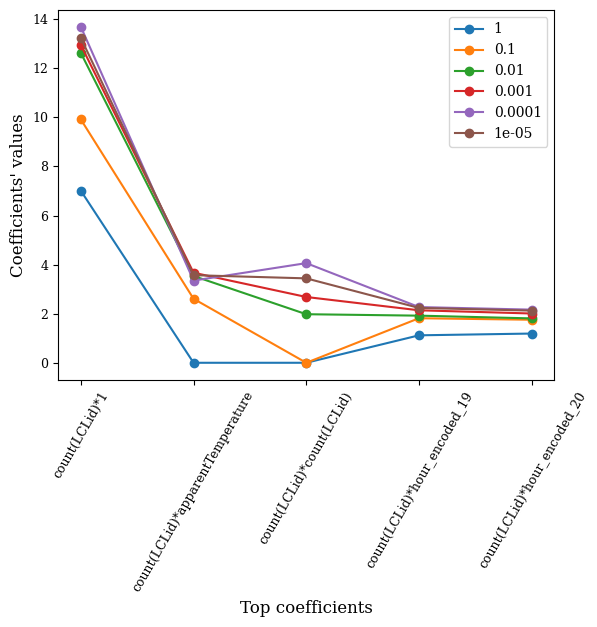

In [ ]:
plt.plot(top[1] ,   '-o',label =1 )
plt.plot(top[0.1] ,   '-o',label =0.1 )
plt.plot(top[0.01] ,   '-o',label =0.01 )
plt.plot(top[0.001] ,   '-o',label =0.001 )
plt.plot(top[0.0001] ,   '-o',label =1e-4 )
plt.plot(top[0.00001] ,   '-o',label =1e-5 )
#plt.xticks(ticks=[0,1,2,3,4],labels = ['Count(LCLid)','Count(LCLid)*App. temperature','Count(LCLid)*Count(LCLid)','Count(LCLid)*Hour #19','Count(LCLid)*Hour #20'],rotation = 60,fontsize =9)
h = plt.xticks(rotation = 60,fontsize =9)

plt.yticks(fontsize = 9)
plt.xlabel('Top coefficients' ,fontsize =12 )
plt.ylabel("Coefficients' values",fontsize =12)
plt.legend()
from google.colab import files

plt.savefig("Effect of lambda on lasso model top 5 coefficients (block 0).png",dpi = 300,bbox_inches= 'tight')
files.download("Effect of lambda on lasso model top 5 coefficients (block 0).png")

In [ ]:
h

([0, 1, 2, 3, 4],
 [Text(0, 0, 'count(LCLid)*1'),
  Text(1, 0, 'count(LCLid)*apparentTemperature'),
  Text(2, 0, 'count(LCLid)*count(LCLid)'),
  Text(3, 0, 'count(LCLid)*hour_encoded_19'),
  Text(4, 0, 'count(LCLid)*hour_encoded_20')])

In [ ]:
len(poly_features_list)

In [ ]:
lasso_coeffs = cvmodel_lasso.bestModel.stages[0].coefficients.values.tolist()
e = {'features':poly_features_list , 'coefficients' :lasso_coeffs }
df_features_coeffs_lasso = pd.DataFrame(data = e)
#df_features_coeffs_lasso_sorted = df_features_coeffs_lasso.sort_values(by= 'coefficients',ascending=False)
df_features_coeffs_lasso['coefficients_abs'] = df_features_coeffs_lasso['coefficients'].apply(abs)
df_features_coeffs_lasso_sorted = df_features_coeffs_lasso.sort_values(by = 'coefficients_abs',ascending=False)

df_features_coeffs_lasso_nonzero = df_features_coeffs_lasso_sorted[df_features_coeffs_lasso_sorted['coefficients_abs'] >0.01]
df_features_coeffs_lasso_nonzero.shape
#df_features_coeffs_lasso_sorted

(122, 3)

In [ ]:
df_features_coeffs_lasso_sorted.head()

,features,coefficients,coefficients_abs
350,count(LCLid)*1,14.084313,14.084313
376,count(LCLid)*count(LCLid),-4.157629,4.157629
374,count(LCLid)*apparentTemperature,-3.519090,3.519090
370,count(LCLid)*hour_encoded_19,2.252655,2.252655
371,count(LCLid)*hour_encoded_20,2.158499,2.158499


## Ridge

In [ ]:
## ridge
from pyspark.ml.regression import LinearRegression
# elasticnetparam = 0 --> ridge regression (L2 penalty )
lr =LinearRegression( featuresCol='poly_features_scaled', labelCol='sum(energy)',elasticNetParam=0.0)
pipeline = Pipeline(stages = [lr])
pipeline.write().overwrite().save("pipeline")
pipelineModel = Pipeline.load("pipeline")
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(predictionCol='prediction', labelCol='sum(energy)', metricName='r2')
# elasticNetParam = Param(parent='undefined', name='elasticNetParam',
#doc='the ElasticNet mixing parameter, in range [0, 1]. For alpha = 0,
#the penalty is an L2 penalty (ridge). For alpha = 1, it is an L1 penalty. (lasso)')
from pyspark.ml.tuning import ParamGridBuilder
paramGrid =  ParamGridBuilder().addGrid(poly.degree,[2]).addGrid(lr.regParam, [1,0.1,0.01,0.001,0.0001,0.00001]).build()
crossval = CrossValidator(estimator=pipelineModel,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=2 ,collectSubModels=True)

In [ ]:
## fit model
from time import time
t0 = time()
cvmodel_ridge = crossval.fit(df_train)
fitting_time_ridge = time() - t0

In [ ]:
print(cvmodel_ridge.getEstimatorParamMaps()[np.argmax(cvmodel_ridge.avgMetrics)])

{Param(parent='PolynomialExpansion_8765fdf90b96', name='degree', doc='the polynomial degree to expand (>= 1)'): 2, Param(parent='LinearRegression_c28236e3edbe', name='regParam', doc='regularization parameter (>= 0).'): 0.0001}


In [ ]:
cvmodel_ridge.avgMetrics

[0.9178454915644668,
 0.9392992573752369,
 0.9435880059276816,
 0.9438227097989628,
 0.9438251559066668,
 0.943825103659055]

In [ ]:
t0 = time()
pred_ridge = cvmodel_ridge.transform(df_test)
predicting_time_ridge = time() - t0
pred_ridge = pred_ridge.withColumn(
    "prediction",
    F.when(pred_ridge["prediction"] < 0, 0.2).otherwise(F.col("prediction")))

In [ ]:
eval =RegressionEvaluator(labelCol="sum(energy)")
r2_ridge = eval.evaluate(pred_ridge,{eval.metricName:"r2"})
rmse_ridge= eval.evaluate(pred_ridge,{eval.metricName:"rmse"})
mse_ridge= eval.evaluate(pred_ridge,{eval.metricName:"mse"})
mae_ridge= eval.evaluate(pred_ridge,{eval.metricName:"mae"})
print('r2 of ridge =' ,r2_ridge)
print('rmse of ridge = ',rmse_ridge)
print('mse of ridge =' , mse_ridge)
print('mae of ridge = ', mae_ridge)

r2 of ridge = 0.9435122440261101
rmse of ridge =  2.5139696551399213
mse of ridge = 6.320043426964336
mae of ridge =  1.7268809600855484


In [ ]:
ridge_coeffs = cvmodel_ridge.bestModel.stages[0].coefficients.values.tolist()
n = {'features':poly_features_list , 'coefficients' :ridge_coeffs }
df_features_coeffs_ridge = pd.DataFrame(data = n)
df_features_coeffs_ridge['coefficients_abs'] = df_features_coeffs_ridge['coefficients'].apply(abs)
df_features_coeffs_ridge_sorted = df_features_coeffs_ridge.sort_values(by = 'coefficients_abs',ascending=False)
df_features_coeffs_ridge_nonzero = df_features_coeffs_ridge_sorted[df_features_coeffs_ridge_sorted['coefficients_abs'] >0.01]

df_features_coeffs_ridge_nonzero.shape

(120, 3)

In [ ]:
df_features_coeffs_ridge_sorted

,features,coefficients,coefficients_abs
350,count(LCLid)*1,15.677972,15.677972
376,count(LCLid)*count(LCLid),-5.155108,5.155108
374,count(LCLid)*apparentTemperature,-3.281763,3.281763
370,count(LCLid)*hour_encoded_19,1.968011,1.968011
371,count(LCLid)*hour_encoded_20,1.865331,1.865331
...,...,...,...
199,hour_encoded_18*hour_encoded_9,0.000000,0.000000
200,hour_encoded_18*hour_encoded_10,0.000000,0.000000
201,hour_encoded_18*hour_encoded_11,0.000000,0.000000
202,hour_encoded_18*hour_encoded_12,0.000000,0.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

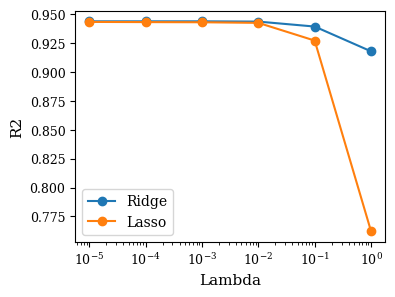

In [ ]:
alphas = [1,0.1,0.01,0.001,0.0001,0.00001]
 #cvmodel_ridge.avgMetrics
 #cvmodel_lasso.avgMetrics
plt.figure(figsize = [4,3])
plt.plot(alphas , cvmodel_ridge.avgMetrics , 'o-' ,label = 'Ridge')
plt.xscale('log')
plt.plot(alphas , cvmodel_lasso.avgMetrics , 'o-',label = 'Lasso')
plt.legend()
from google.colab import files
plt.xlabel('Lambda', fontsize = 11) ;
plt.ylabel('R2' , fontsize =11) ;
plt.xticks(fontsize = 9);
plt.yticks(fontsize = 9);
plt.savefig("Ridge and lasso lambdas aganist R2.png",dpi = 300,bbox_inches= 'tight')
files.download("Ridge and lasso lambdas aganist R2.png")

## Elastic net

In [ ]:
## elastic net
from pyspark.ml.regression import LinearRegression
# elasticnetparam = 0 --> ridge regression (L2 penalty )
lr =LinearRegression( featuresCol='poly_features_scaled', labelCol='sum(energy)')
pipeline = Pipeline(stages = [lr])
pipeline.write().overwrite().save("pipeline")
pipelineModel = Pipeline.load("pipeline")
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(predictionCol='prediction', labelCol='sum(energy)', metricName='r2')
from pyspark.ml.tuning import ParamGridBuilder
paramGrid =  ParamGridBuilder().addGrid(poly.degree,[2]).addGrid(lr.regParam, [1,0.1,0.01,0.001,0.0001,0.00001]).addGrid(lr.elasticNetParam ,[0,0.1,0.2,0.5,0.7,0.8,1]).build()
crossval = CrossValidator(estimator=pipelineModel,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=2 ,collectSubModels=True)

In [ ]:
## fit model
t0 = time()
cvmodel_elastic = crossval.fit(df_train)
fitting_time_elastic = time() - t0

In [ ]:
print(cvmodel_elastic.getEstimatorParamMaps()[np.argmax(cvmodel_elastic.avgMetrics)])

{Param(parent='PolynomialExpansion_8765fdf90b96', name='degree', doc='the polynomial degree to expand (>= 1)'): 2, Param(parent='LinearRegression_27cfd88ae83b', name='regParam', doc='regularization parameter (>= 0).'): 0.0001, Param(parent='LinearRegression_27cfd88ae83b', name='elasticNetParam', doc='the ElasticNet mixing parameter, in range [0, 1]. For alpha = 0, the penalty is an L2 penalty. For alpha = 1, it is an L1 penalty.'): 0.0}


In [ ]:
t0 = time()
pred_elastic = cvmodel_elastic.transform(df_test)
predicting_time_elastic = time() - t0

In [ ]:
pred_elastic = pred_elastic.withColumn(
    "prediction",
    F.when(pred_elastic["prediction"] < 0, 0.2).otherwise(F.col("prediction")))

In [ ]:
eval =RegressionEvaluator(labelCol="sum(energy)")
r2_elastic = eval.evaluate(pred_elastic,{eval.metricName:"r2"})
rmse_elastic= eval.evaluate(pred_elastic,{eval.metricName:"rmse"})
mse_elastic= eval.evaluate(pred_elastic,{eval.metricName:"mse"})
mae_elastic= eval.evaluate(pred_elastic,{eval.metricName:"mae"})
print('r2 of elastic net  =' ,r2_elastic)
print('rmse elastic net = ',rmse_elastic)
print('mse elastic net=' , mse_elastic)
print('mae elastic net= ', mae_elastic)

r2 of elastic net  = 0.9435122440261101
rmse elastic net =  2.5139696551399213
mse elastic net= 6.320043426964336
mae elastic net=  1.7268809600855484


In [ ]:
elastic_coeffs = cvmodel_elastic.bestModel.stages[0].coefficients.values.tolist()
n = {'features':poly_features_list , 'coefficients' :ridge_coeffs }
df_features_coeffs_elastic = pd.DataFrame(data = n)
df_features_coeffs_elastic['coefficients_abs'] = df_features_coeffs_elastic['coefficients'].apply(abs)

df_features_coeffs_elastic_sorted = df_features_coeffs_elastic.sort_values(by= 'coefficients_abs',ascending=False)
#df_features_coeffs_elastic_nonzero = df_features_coeffs_elastic_sorted[df_features_coeffs_elastic_sorted['coefficients'] >0]
#df_features_coeffs_elastic_nonzero
df_features_coeffs_elastic_sorted

,features,coefficients,coefficients_abs
350,count(LCLid)*1,15.677972,15.677972
376,count(LCLid)*count(LCLid),-5.155108,5.155108
374,count(LCLid)*apparentTemperature,-3.281763,3.281763
370,count(LCLid)*hour_encoded_19,1.968011,1.968011
371,count(LCLid)*hour_encoded_20,1.865331,1.865331
...,...,...,...
199,hour_encoded_18*hour_encoded_9,0.000000,0.000000
200,hour_encoded_18*hour_encoded_10,0.000000,0.000000
201,hour_encoded_18*hour_encoded_11,0.000000,0.000000
202,hour_encoded_18*hour_encoded_12,0.000000,0.000000


In [ ]:
df_features_coeffs_elastic_nonzero.shape

In [ ]:
pred_lasso.show(10)

In [ ]:
pred_p= pred_plain.select('time2','prediction','sum(energy)')
pred_l= pred_lasso.select('time2','prediction','sum(energy)')
pred_r= pred_ridge.select('time2','prediction','sum(energy)')
pred_e= pred_elastic.select('time2','prediction','sum(energy)')

In [ ]:
pred_plain_train = cvmodel.transform(df_train)
pred_lasso_train = cvmodel_lasso.transform(df_train)
pred_ridge_train = cvmodel_ridge.transform(df_train)
pred_elastic_train = cvmodel_elastic.transform(df_train)

In [ ]:
pred_plain_train = pred_plain_train.select('time2','prediction','sum(energy)')
pred_lasso_train= pred_lasso_train.select('time2','prediction','sum(energy)')
pred_ridge_train= pred_ridge_train.select('time2','prediction','sum(energy)')
pred_elastic_train= pred_elastic_train.select('time2','prediction','sum(energy)')

In [ ]:
pred_plain = pred_plain_train.union(pred_p)
pred_lasso= pred_lasso_train.union(pred_l)
pred_ridge = pred_ridge_train.union(pred_r)
pred_elastic= pred_elastic_train.union(pred_e)

In [ ]:
pred_plain = pred_plain.toPandas()
pred_lasso = pred_lasso.toPandas()
pred_ridge= pred_ridge.toPandas()
pred_elastic = pred_elastic.toPandas()
pred_plain['time2'] =pred_plain['time2'].astype('datetime64')
pred_lasso['time2'] =pred_lasso['time2'].astype('datetime64')
pred_ridge['time2'] =pred_ridge['time2'].astype('datetime64')
pred_elastic['time2'] =pred_elastic['time2'].astype('datetime64')

In [ ]:
pred_plain.sort_values(by = ['time2'],inplace =True )
pred_lasso.sort_values(by = ['time2'],inplace =True )
pred_ridge.sort_values(by = ['time2'],inplace =True )
pred_elastic.sort_values(by = ['time2'],inplace =True )

## regression tree model

In [ ]:
df1.show(5)

+------------------+------------+-------------------+-------------------+----+--------+
|       sum(energy)|count(LCLid)|              time2|apparentTemperature|hour|week_end|
+------------------+------------+-------------------+-------------------+----+--------+
|1.5479999482631683|         4.0|2012-04-08 07:00:00|               5.03| 7.0|       1|
| 5.970000050961971|         5.0|2012-04-22 22:00:00|               5.14|22.0|       1|
|3.0740000158548355|         7.0|2012-06-15 04:00:00|               13.2| 4.0|       0|
| 7.218999914824963|        10.0|2012-07-28 00:00:00|              16.84| 0.0|       1|
| 6.906999919563532|        10.0|2012-08-11 16:00:00|              21.23|16.0|       1|
+------------------+------------+-------------------+-------------------+----+--------+
only showing top 5 rows



In [ ]:
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler
vector_assembler = VectorAssembler(inputCols = ['hour','apparentTemperature' ,'week_end','count(LCLid)']
                                   ,outputCol = 'features_vector')
df1 = vector_assembler.transform(df1)
df1.show(3)

+------------------+------------+-------------------+-------------------+----+--------+-------------------+
|       sum(energy)|count(LCLid)|              time2|apparentTemperature|hour|week_end|    features_vector|
+------------------+------------+-------------------+-------------------+----+--------+-------------------+
|1.5479999482631683|         4.0|2012-04-08 07:00:00|               5.03| 7.0|       1| [7.0,5.03,1.0,4.0]|
| 5.970000050961971|         5.0|2012-04-22 22:00:00|               5.14|22.0|       1|[22.0,5.14,1.0,5.0]|
|3.0740000158548355|         7.0|2012-06-15 04:00:00|               13.2| 4.0|       0| [4.0,13.2,0.0,7.0]|
+------------------+------------+-------------------+-------------------+----+--------+-------------------+
only showing top 3 rows



In [ ]:
df_train ,df_test = df1.randomSplit([0.8,0.2])
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(predictionCol='prediction', labelCol='sum(energy)', metricName='r2')
from pyspark.ml.regression import DecisionTreeRegressor
DTR = DecisionTreeRegressor(featuresCol= 'features_vector', labelCol= 'sum(energy)')
from pyspark.ml.tuning import ParamGridBuilder
#depth = range(3,30,2)
paramGrid =  ParamGridBuilder().addGrid(DTR.maxDepth, [9,10,11,12]).addGrid(DTR.maxBins , [32 , 40 ,50]).build()
crossval = CrossValidator(estimator=DTR,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=3
                          ,collectSubModels=True
                          )

In [ ]:
from time import time
t0 =time()
cvmodel_tree = crossval.fit(df_train)
fitting_time_tree = time() - t0

In [ ]:
t0 = time()
pred_tree = cvmodel_tree.transform(df_test)
predicting_time_tree = time() -t0

In [ ]:
DTRM = cvmodel_tree.bestModel

In [ ]:
DTRM

DecisionTreeRegressionModel: uid=DecisionTreeRegressor_e66afaa65be2, depth=10, numNodes=1617, numFeatures=4

In [ ]:
DTRM = cvmodel_tree.bestModel
def tree_json(tree):
	data = []
	for line in tree.splitlines() :
		if line.strip():
			line = line.strip()
			data.append(line)
		else : break
		if not line : break
	res = []
	res.append({'name':'Root', 'children':parse(data[1:])})
	with open('/content/drive/MyDrive/decision_rules_load.txt', 'w') as outfile:
		json.dump(res[0], outfile)
	print ('Conversion Success !')
def parse(lines):
		block = []
		while lines :

			if lines[0].startswith('If'):
				bl = ' '.join(lines.pop(0).split()[1:]).replace('(', '').replace(')', '')
				block.append({'name':bl, 'children':parse(lines)})


				if lines[0].startswith('Else'):
					be = ' '.join(lines.pop(0).split()[1:]).replace('(', '').replace(')', '')
					block.append({'name':be, 'children':parse(lines)})
			elif not lines[0].startswith(('If','Else')):
				block2 = lines.pop(0)
				block.append({'name':block2})
			else:
				break
		return block

In [ ]:
tree_to_plot = DTRM.toDebugString

In [ ]:
tree_to_plot

'DecisionTreeRegressionModel: uid=DecisionTreeRegressor_e66afaa65be2, depth=10, numNodes=1617, numFeatures=4\n  If (feature 3 <= 21.5)\n   If (feature 3 <= 6.5)\n    If (feature 3 <= 3.5)\n     If (feature 0 <= 2.5)\n      If (feature 0 <= 0.5)\n       If (feature 3 <= 2.5)\n        If (feature 1 <= 5.365)\n         If (feature 1 <= 2.295)\n          If (feature 1 <= 0.135)\n           If (feature 2 <= 0.5)\n            Predict: 0.6555000074207783\n           Else (feature 2 > 0.5)\n            Predict: 0.861285707780293\n          Else (feature 1 > 0.135)\n           If (feature 1 <= 1.7850000000000001)\n            Predict: 0.4482499989680946\n           Else (feature 1 > 1.7850000000000001)\n            Predict: 0.6255000047385693\n         Else (feature 1 > 2.295)\n          If (feature 1 <= 3.915)\n           If (feature 1 <= 3.535)\n            Predict: 0.9002499952912331\n           Else (feature 1 > 3.535)\n            Predict: 0.8134000048041343\n          Else (feature 1 > 3.

In [ ]:
! pip uninstall bson
! pip uninstall pymongo
! pip install pymongo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.3/671.3 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 9.9 MB/s eta 0:00:00


In [ ]:
import json
from bson import json_util
from bson.json_util import dumps
tree_json(DTRM.toDebugString)

Conversion Success !


In [ ]:
df1.schema['features_vector'].metadata["ml_attr"]["attrs"]

{'numeric': [{'idx': 0, 'name': 'hour'},
  {'idx': 1, 'name': 'apparentTemperature'},
  {'idx': 2, 'name': 'week_end'},
  {'idx': 3, 'name': 'count(LCLid)'}]}

In [ ]:
eval =RegressionEvaluator(labelCol="sum(energy)")
r2_tree = eval.evaluate(pred_tree,{eval.metricName:"r2"})
rmse_tree = eval.evaluate(pred_tree,{eval.metricName:"rmse"})
mse_tree = eval.evaluate(pred_tree,{eval.metricName:"mse"})
mae_tree = eval.evaluate(pred_tree,{eval.metricName:"mae"})
print('r2 of decision tree = ',r2_tree)
print('rmse of decision tree = ',rmse_tree)
print('mse of decision tree = ',mse_tree)
print('mae of decision tree = ',mae_tree)

r2 of decision tree =  0.948994143622071
rmse of decision tree =  2.3529025253601716
mse of decision tree =  5.536150293846273
mae of decision tree =  1.5031683649469787


In [ ]:
pred_tree_tarin = cvmodel_tree.transform(df_train)

In [ ]:
pred_tree = pred_tree_tarin.union(pred_tree)

In [ ]:
pred_tree = pred_tree.toPandas()

In [ ]:
pred_tree.to_csv('/content/drive/MyDrive/predictions_regressiontree_block0_evaluation_dtou.csv')

In [ ]:
pred_tree['time2'] =pred_tree['time2'].astype('datetime64')
pred_tree.sort_values(by = ['time2'],inplace =True )


In [ ]:
pred_plain_2013 = pred_plain[(pred_plain['time2'] > '2013-03-26 00:00:00') & (pred_plain['time2'] <= '2013-03-31 00:00:00')]
pred_lasso_2013 = pred_lasso[(pred_plain['time2'] > '2013-03-26 00:00:00') & (pred_lasso['time2'] <= '2013-03-31 00:00:00')]
pred_ridge_2013 = pred_ridge[(pred_plain['time2'] > '2013-03-26 00:00:00') & (pred_ridge['time2'] <= '2013-03-31 00:00:00')]
pred_elastic_2013 = pred_elastic[(pred_plain['time2'] > '2013-03-26 00:00:00') & (pred_elastic['time2'] <= '2013-03-31 00:00:00')]
pred_tree_2013 = pred_tree[(pred_tree['time2'] > '2013-03-26 00:00:00') & (pred_tree['time2'] <= '2013-03-31 00:00:00')]

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

In [ ]:
pred_plain_2013_p1_1d = pred_plain[(pred_plain['time2'] > '2013-04-22 00:00:00') & (pred_plain['time2'] <= '2013-04-24 00:00:00')]
pred_lasso_2013_p1_1d = pred_lasso[(pred_plain['time2'] > '2013-04-22 00:00:00') & (pred_lasso['time2'] <= '2013-04-24 00:00:00')]
pred_ridge_2013_p1_1d = pred_ridge[(pred_plain['time2'] > '2013-04-22 00:00:00') & (pred_ridge['time2'] <= '2013-04-24 00:00:00')]
pred_elastic_2013_p1_1d = pred_elastic[(pred_plain['time2'] > '2013-04-22 00:00:00') & (pred_elastic['time2'] <= '2013-04-24 00:00:00')]
#pred_tree_2013 = pred_tree[(pred_tree['time2'] > '2013-04-22 00:00:00') & (pred_tree['time2'] <= '2013-04-24 00:00:00')]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

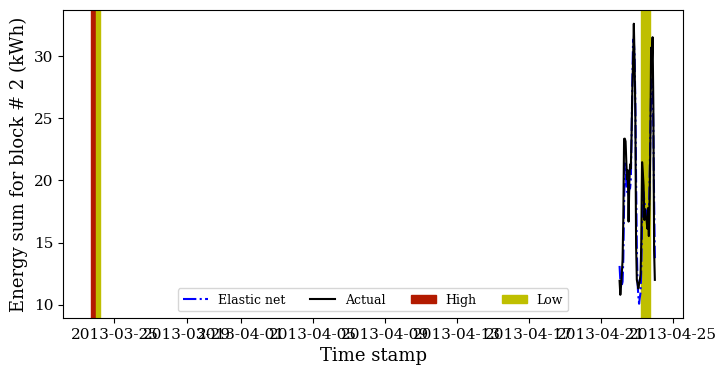

In [ ]:
plt.figure(figsize=[8,4])

plt.xlabel('Time stamp',fontsize = 13 ,fontweight = 540)
plt.ylabel('Energy sum for block # 2 (kWh)',fontsize = 13, fontweight =540)
plt.yticks(fontsize = 11,fontweight = 545)
plt.xticks(fontsize = 11  ,fontweight = 545)

#plt.plot(pred_plain_2013['time2'] ,pred_plain_2013['prediction'], linestyle='--', linewidth = 1.5,color ='g',label = 'Plain')
#plt.plot(pred_lasso_2013['time2'] ,pred_lasso_2013['prediction'], linestyle='-.', linewidth = 1.5,color ='c',label = 'Lasso')
#plt.plot(pred_ridge_2013['time2'] ,pred_ridge_2013['prediction'], linestyle='-.', linewidth = 1.5,color='r',label ='Ridge')
plt.plot(pred_elastic_2013_p1_1d['time2'] ,pred_elastic_2013_p1_1d['prediction'], linestyle='-.', linewidth = 1.5,color= 'b',label ='Elastic net')
#plt.plot(pred_tree_2013['time2'] ,pred_tree_2013['prediction'], linestyle='--', linewidth = 1.5,color= 'b',label = 'DTR')
plt.plot(pred_elastic_2013_p1_1d['time2'] ,pred_elastic_2013_p1_1d['sum(energy)'], linestyle='-', linewidth = 1.5 ,color= 'k',label= 'Actual')
plt.axvspan(xmin = '2013-04-23 05:00:00' ,xmax ='2013-04-23 17:00:00', color ='y'  )
plt.axvspan(xmin = '2013-03-23 17:00:00' ,xmax ='2013-03-23 23:00:00', color = (0.7 ,0.1,0) ,label ='High' )
plt.axvspan(xmin = '2013-03-23 23:00:00' ,xmax ='2013-03-24 05:00:00', color ='y' ,label = 'Low'  )
#plt.axvspan(xmin = '2013-03-28 17:00:00' ,xmax ='2013-03-28 23:00:00', color = (0.7 ,0.1,0)  )
#plt.axvspan(xmin = '2013-03-28 23:00:00' ,xmax ='2013-03-30 05:00:00', color ='y'  )
#plt.axvspan(xmin = '2013-03-17 23:00:00' ,xmax ='2013-03-18 05:00:00', color =(0.1,0.9,0.1)  )

plt.legend(loc=0,ncols = 4 ,fontsize = 9)
from google.colab import files
plt.savefig("Actual and predicted for all block 2 with CM event (p1_1d).png",dpi = 300,bbox_inches= 'tight')
files.download("Actual and predicted for all block 2 with CM event (p1_1d).png")

### P1_2D_0 Tue, 26 Nov Thu, 28 Nov 17:00 23:00

In [ ]:
pred_plain_2013_p1_1d = pred_plain[(pred_plain['time2'] > '2013-11-25 00:00:00') & (pred_plain['time2'] <= '2013-04-24 00:00:00')]
pred_lasso_2013_p1_1d = pred_lasso[(pred_plain['time2'] > '2013-04-22 00:00:00') & (pred_lasso['time2'] <= '2013-04-24 00:00:00')]
pred_ridge_2013_p1_1d = pred_ridge[(pred_plain['time2'] > '2013-04-22 00:00:00') & (pred_ridge['time2'] <= '2013-04-24 00:00:00')]
pred_elastic_2013_p1_1d = pred_elastic[(pred_plain['time2'] > '2013-04-22 00:00:00') & (pred_elastic['time2'] <= '2013-04-24 00:00:00')]
#pred_tree_2013 = pred_tree[(pred_tree['time2'] > '2013-04-22 00:00:00') & (pred_tree['time2'] <= '2013-04-24 00:00:00')]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

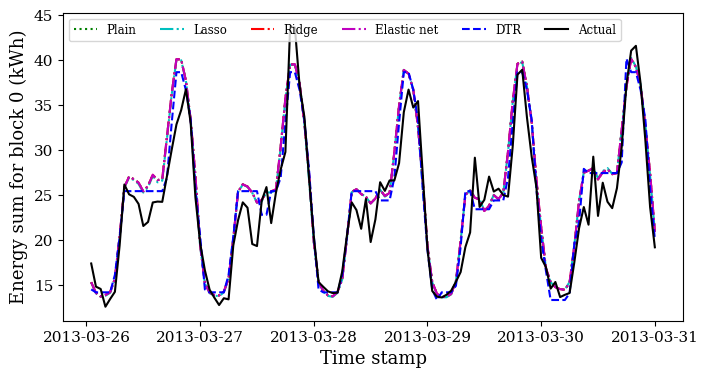

In [ ]:
plt.figure(figsize=[8,4])

plt.xlabel('Time stamp',fontsize = 13 ,fontweight = 540)
plt.ylabel('Energy sum for block 0 (kWh)',fontsize = 13, fontweight =540)
plt.yticks(fontsize = 11,fontweight = 545)
plt.xticks(fontsize = 11  ,fontweight = 545)

plt.plot(pred_plain_2013['time2'] ,pred_plain_2013['prediction'], linestyle=':', color ='g',label = 'Plain')
plt.plot(pred_lasso_2013['time2'] ,pred_lasso_2013['prediction'], linestyle='-.' ,color ='c',label = 'Lasso')
plt.plot(pred_ridge_2013['time2'] ,pred_ridge_2013['prediction'], linestyle='-.', color='r',label ='Ridge')
plt.plot(pred_elastic_2013['time2'] ,pred_elastic_2013['prediction'], linestyle='-.', markersize=4,color= 'm',label ='Elastic net')
plt.plot(pred_tree_2013['time2'] ,pred_tree_2013['prediction'], linestyle='--',color= 'b',label = 'DTR')
plt.plot(pred_plain_2013['time2'] ,pred_lasso_2013['sum(energy)'],linestyle='-', color= 'k',label= 'Actual')
plt.legend(loc='upper left',ncols = 6 ,fontsize = 8.5)
from google.colab import files

plt.savefig("Actual and predicted energies for block 0.png",dpi = 300,bbox_inches= 'tight')
files.download("Actual and predicted energies for block 0.png")

In [ ]:
pred_plain_2013 = pred_plain[(pred_plain['time2'] > '2013-03-14 00:00:00') & (pred_plain['time2'] <= '2013-03-19 00:00:00')]
pred_lasso_2013 = pred_lasso[(pred_plain['time2'] > '2013-03-14 00:00:00') & (pred_lasso['time2'] <= '2013-03-19 00:00:00')]
pred_ridge_2013 = pred_ridge[(pred_plain['time2'] > '2013-03-14 00:00:00') & (pred_ridge['time2'] <= '2013-03-19 00:00:00')]
pred_elastic_2013 = pred_elastic[(pred_plain['time2'] > '2013-03-14 00:00:00') & (pred_elastic['time2'] <= '2013-03-19 00:00:00')]
pred_tree_2013 = pred_tree[(pred_tree['time2'] > '2013-03-14 00:00:00') & (pred_tree['time2'] <= '2013-03-19 00:00:00')]

In [ ]:
pred_plain.head(10)

,time2,prediction,sum(energy)
15056,2011-12-03 09:00:00,0.406864,0.149
13858,2011-12-03 10:00:00,1.187541,0.768
8398,2011-12-03 11:00:00,1.873086,0.588
5204,2011-12-03 12:00:00,1.842676,0.843
10809,2011-12-03 13:00:00,1.562686,0.120
5519,2011-12-03 14:00:00,1.125951,0.053
12267,2011-12-03 15:00:00,1.194577,0.047
6925,2011-12-03 16:00:00,0.968230,0.063
13137,2011-12-03 17:00:00,1.296955,0.110
2355,2011-12-03 18:00:00,1.911957,0.076


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

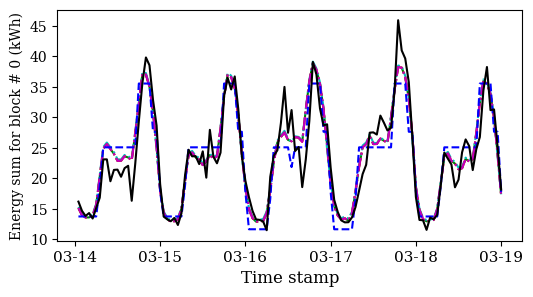

In [ ]:
plt.figure(figsize=[6,3])

plt.xlabel('Time stamp',fontsize = 12 ,fontweight = 540)
plt.ylabel('Energy sum for block # 0 (kWh)',fontsize = 10, fontweight =540)
plt.yticks(fontsize = 10,fontweight = 545)
r = plt.xticks(fontsize = 11  ,fontweight = 545,ticks= [15778,15779,15780,15781,15782,15783],labels=['03-14','03-15','03-16','03-17','03-18','03-19'])
#
plt.plot(pred_plain_2013['time2'] ,pred_plain_2013['prediction'], linestyle='--', markersize=4,color ='g',label = 'Plain')
plt.plot(pred_lasso_2013['time2'] ,pred_lasso_2013['prediction'], linestyle='-.', markersize=4,color ='c',label = 'Lasso')
plt.plot(pred_ridge_2013['time2'] ,pred_ridge_2013['prediction'], linestyle='-.', markersize=4,color='r',label ='Ridge')
plt.plot(pred_elastic_2013['time2'] ,pred_elastic_2013['prediction'], linestyle='-.', markersize=4,color= 'm',label ='Elastic net')
plt.plot(pred_tree_2013['time2'] ,pred_tree_2013['prediction'], linestyle='--', markersize=4,color= 'b',label = 'RT')
plt.plot(pred_plain_2013['time2'] ,pred_ridge_2013['sum(energy)'], linestyle='-', markersize=4 ,color= 'k',label= 'Actual')
#plt.legend(loc=0,ncols = 6,fontsize = 8)
from google.colab import files
plt.savefig("Actual and predicted energies for block 0.png",dpi = 300,bbox_inches= 'tight')
files.download("Actual and predicted energies for block 0.png")

In [ ]:
r

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(15778.0, 0, '2013-03-14'),
  Text(15779.0, 0, '2013-03-15'),
  Text(15780.0, 0, '2013-03-16'),
  Text(15781.0, 0, '2013-03-17'),
  Text(15782.0, 0, '2013-03-18'),
  Text(15783.0, 0, '2013-03-19')])

In [ ]:
import matplotlib.lines as mlines
from google.colab import files
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
import matplotlib.patches as mpatches
figlegend = plt.figure(figsize=(9.25,0.5))
plain = mlines.Line2D([], [], color='g', linestyle='--',lw=2,
                          markersize=10, label='Plain')
lasso = mlines.Line2D([], [], color='c', linestyle='-.',lw=2,
                          markersize=10, label='Lasso')
ridge = mlines.Line2D([], [], color='r', linestyle='-.',lw=2,
                          markersize=10, label='Ridge')
elastic = mlines.Line2D([], [], color='m', linestyle='-.',lw=2,
                          markersize=10, label='Elastic net')
dtr = mlines.Line2D([], [], color='b', linestyle='--',lw=2,
                          markersize=10, label='DTR')
actual = mlines.Line2D([], [], color='k', linestyle='-',lw=2,
                          markersize=10, label='Actual')



figlegend.legend(handles=[plain, lasso, ridge,elastic , dtr, actual] ,ncols =6,fontsize =14,edgecolor = 'k' , framealpha=1)

figlegend.savefig('legend.png',dpi=300)
files.download("legend.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 925x50 with 0 Axes>

In [ ]:
d

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(15790.0, 0, '2013-03-26'),
  Text(15791.0, 0, '2013-03-27'),
  Text(15792.0, 0, '2013-03-28'),
  Text(15793.0, 0, '2013-03-29'),
  Text(15794.0, 0, '2013-03-30'),
  Text(15795.0, 0, '2013-03-31')])

In [ ]:
print('fitting time of plain linear regression model = ' ,fitting_time_lr )
print('predicting time of plain linear regression model = ' ,predicting_time_lr )
print('fitting time of lasso regression model = ' ,fitting_time_lasso )
print('predicting time of lasso regression model = ' ,predicting_time_lasso )
print('fitting time of ridge regression model = ' ,fitting_time_ridge )
print('predicting time of ridge regression model = ' ,predicting_time_ridge )
print('fitting time of elastic regression model = ' ,fitting_time_elastic )
print('predicting time of elastic regression model = ' ,predicting_time_elastic )
print('fitting time of RT  model = ' ,fitting_time_tree )
print('predicting time of RT model = ' ,predicting_time_tree )

fitting time of plain linear regression model =  38.9027419090271
predicting time of plain linear regression model =  0.023177146911621094
fitting time of lasso regression model =  167.32590222358704
predicting time of lasso regression model =  0.017412424087524414
fitting time of ridge regression model =  76.58500146865845
predicting time of ridge regression model =  0.017392396926879883
fitting time of elastic regression model =  436.63536500930786
predicting time of elastic regression model =  0.019155502319335938
fitting time of RT  model =  114.24528813362122
predicting time of RT model =  0.016950607299804688
